## **Predicting Air Quality Index**


### **Load Python Packages**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import mstats
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score


import warnings
warnings.filterwarnings('ignore')

### **Read the Air Quality Data**

In [2]:
aqi_data = pd.read_csv('AQI and Lat Long of Countries.csv')

data_dim = aqi_data.shape
print("Shape of AQI Data: ", data_dim)
print("Number of data points: ", data_dim[0])
print("Number of features: ", data_dim[1])

Shape of AQI Data:  (16695, 14)
Number of data points:  16695
Number of features:  14


In [3]:
aqi_data.head(3)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,44.7444,44.2031
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,-5.2900,-44.4900
2,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,-11.2958,-41.9869


### **Exploratory Data Analysis**

In [4]:
aqi_data.describe().T

,count,mean,std,min,25%,50%,75%,max
AQI Value,16695.0,62.998682,43.091971,7.0000,38.50000,52.0000,69.0000,500.0000
CO AQI Value,16695.0,1.342138,2.371379,0.0000,1.00000,1.0000,1.0000,133.0000
Ozone AQI Value,16695.0,31.767355,22.839343,0.0000,20.00000,29.0000,38.0000,222.0000
NO2 AQI Value,16695.0,3.819647,5.880677,0.0000,0.00000,2.0000,5.0000,91.0000
PM2.5 AQI Value,16695.0,59.821324,43.208298,0.0000,34.00000,52.0000,69.0000,500.0000
lat,16695.0,30.267148,22.947398,-54.8019,16.51545,38.8158,46.6833,70.7670
lng,16695.0,-3.944485,73.037148,-171.7500,-75.18000,5.6431,36.2750,178.0178


#### Analysis of Dtypes of Features

In [5]:
aqi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16695 entries, 0 to 16694
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             16393 non-null  object 
 1   City                16695 non-null  object 
 2   AQI Value           16695 non-null  int64  
 3   AQI Category        16695 non-null  object 
 4   CO AQI Value        16695 non-null  int64  
 5   CO AQI Category     16695 non-null  object 
 6   Ozone AQI Value     16695 non-null  int64  
 7   Ozone AQI Category  16695 non-null  object 
 8   NO2 AQI Value       16695 non-null  int64  
 9   NO2 AQI Category    16695 non-null  object 
 10  PM2.5 AQI Value     16695 non-null  int64  
 11  PM2.5 AQI Category  16695 non-null  object 
 12  lat                 16695 non-null  float64
 13  lng                 16695 non-null  float64
dtypes: float64(2), int64(5), object(7)
memory usage: 1.8+ MB


In [6]:
object_features = aqi_data.select_dtypes(include=['object']).columns
object_features 

Index(['Country', 'City', 'AQI Category', 'CO AQI Category',
       'Ozone AQI Category', 'NO2 AQI Category', 'PM2.5 AQI Category'],
      dtype='object')

In [7]:
float_features = aqi_data.select_dtypes(include=['float']).columns
float_features

Index(['lat', 'lng'], dtype='object')

In [8]:
int_features = aqi_data.select_dtypes(include=['int']).columns
int_features

Index(['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value',
       'PM2.5 AQI Value'],
      dtype='object')

#### Presence of NA/missing data

In [9]:
na_counts = aqi_data.isna().sum()
na_counts

Country               302
City                    0
AQI Value               0
AQI Category            0
CO AQI Value            0
CO AQI Category         0
Ozone AQI Value         0
Ozone AQI Category      0
NO2 AQI Value           0
NO2 AQI Category        0
PM2.5 AQI Value         0
PM2.5 AQI Category      0
lat                     0
lng                     0
dtype: int64

#### Presence of Duplicate Data

In [10]:
total_duplicate_rows = aqi_data.duplicated().sum()
total_duplicate_rows

np.int64(0)

#### Presence of Unique Data

In [11]:
unique_count = aqi_data.nunique()
unique_count

Country                 174
City                  14229
AQI Value               282
AQI Category              6
CO AQI Value             31
CO AQI Category           3
Ozone AQI Value         203
Ozone AQI Category        5
NO2 AQI Value            56
NO2 AQI Category          2
PM2.5 AQI Value         298
PM2.5 AQI Category        6
lat                   14135
lng                   14896
dtype: int64

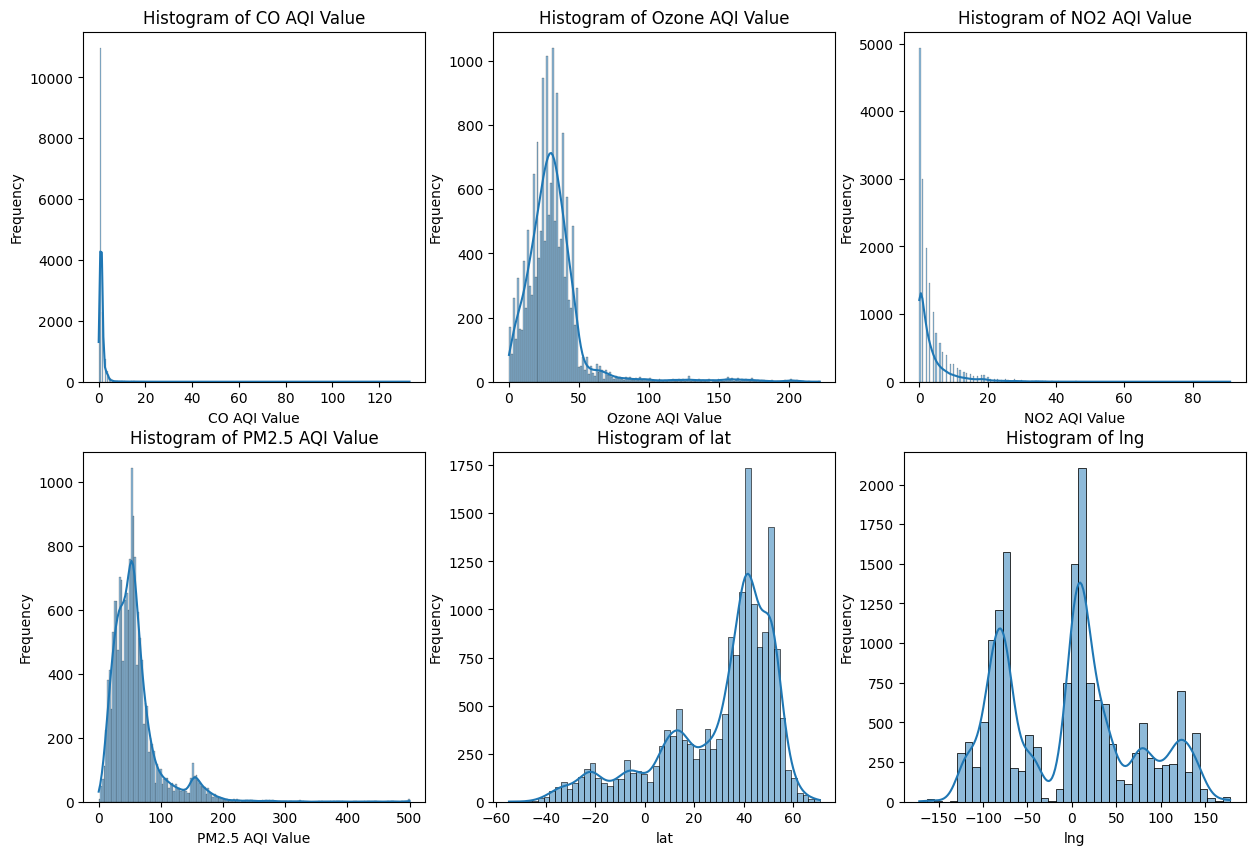

In [12]:
numerical_features = [col for col in aqi_data.columns if aqi_data[col].dtype in ['int64', 'float64']]
ig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()
for i, feature in enumerate(numerical_features[1:]):
    sns.histplot(aqi_data[feature], ax=axes[i], kde=True)
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

#### Distribution of AQI

Text(0, 0.5, 'Frequency')

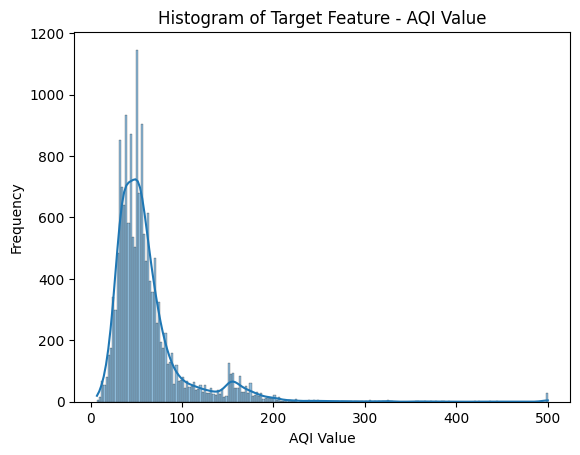

In [13]:
sns.histplot(aqi_data[numerical_features[0]], kde=True)
plt.title(f'Histogram of Target Feature - {numerical_features[0]}')
plt.xlabel(numerical_features[0])
plt.ylabel('Frequency')

#### Categorical Distribution of AQI Category

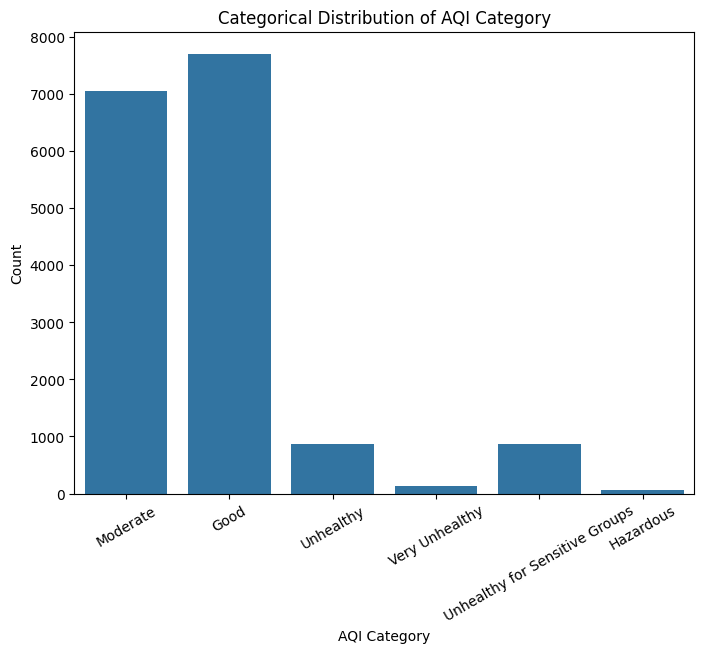

In [14]:
plt.figure(figsize=(8, 6))
sns.countplot(x='AQI Category', data=aqi_data)

plt.title('Categorical Distribution of AQI Category')
plt.xlabel('AQI Category')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

#### Correlation Analysis

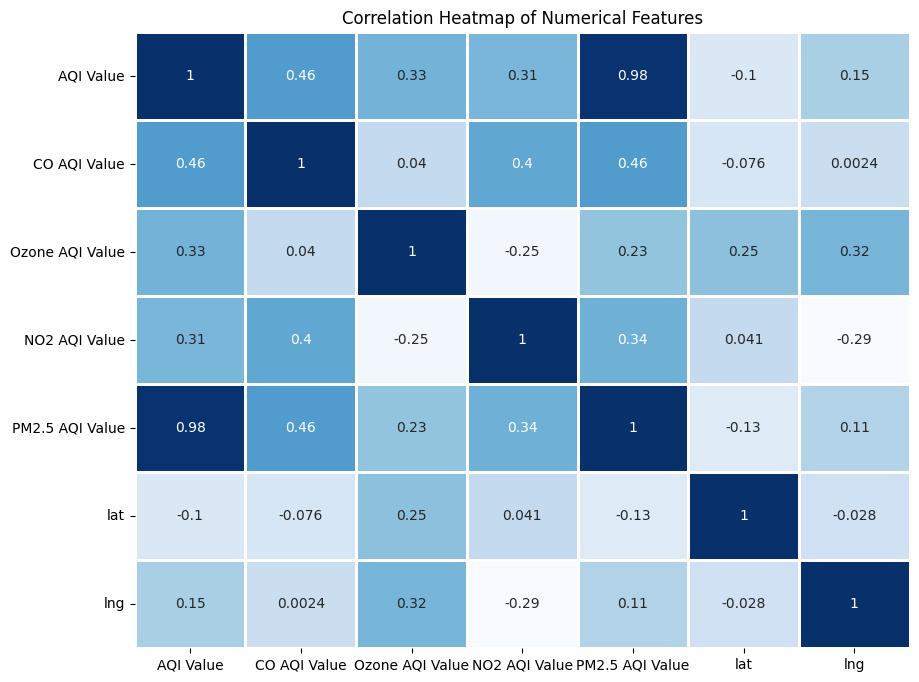

In [15]:
correlation_matrix = aqi_data[numerical_features].corr()
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', linewidths=2, linecolor='white', cbar=False)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [16]:
correlation_matrix["AQI Value"]

AQI Value          1.000000
CO AQI Value       0.458523
Ozone AQI Value    0.327956
NO2 AQI Value      0.308858
PM2.5 AQI Value    0.980360
lat               -0.099554
lng                0.150662
Name: AQI Value, dtype: float64

### **Data Preprocessing**

1. Remove NA from country feature and drop  PM2.5 AQI Value.
2. No Duplicates Present

#### Remove NA

In [17]:
aqi_data.shape
aqi_data_cleaned = aqi_data.dropna(subset=['Country'])
aqi_data_cleaned.shape

(16393, 14)

NA data has been removed

#### Encode Categorical (Object) Type Features

In [18]:
label_encoder = LabelEncoder()

for col in object_features:
    le = LabelEncoder()
    aqi_data_cleaned[col] = le.fit_transform(aqi_data_cleaned[col])

    # save encoder of this column
    pickle.dump(le, open(f"{col}_encoder.pkl", "wb"))

aqi_data_cleaned.head(3)

,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,lat,lng
0,130,9931,51,2,1,0,36,0,0,0,51,2,44.7444,44.2031
1,22,9945,41,0,1,0,5,0,1,0,41,0,-5.2900,-44.4900
2,22,9945,41,0,1,0,5,0,1,0,41,0,-11.2958,-41.9869


#### Data Splitting and Normalise Data

In [19]:
# drop PM2.5 AQI Value due to it is highly correlated to target whihc may affect the results
X =  aqi_data_cleaned.drop(['AQI Value', 'PM2.5 AQI Value'], axis=1)
y = aqi_data_cleaned['AQI Value']

In [20]:
numerical_features.extend(object_features)

In [21]:
# Initialise the MinMaxScaler
scaler = MinMaxScaler()

X[X.columns] = scaler.fit_transform(X[X.columns])

X.head(3)

,Country,City,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Category,lat,lng
0,0.751445,0.711645,0.4,0.007519,0.0,0.162162,0.0,0.000000,0.0,0.4,0.792762,0.603851
1,0.127168,0.712648,0.0,0.007519,0.0,0.022523,0.0,0.010989,0.0,0.0,0.394301,0.341281
2,0.127168,0.712648,0.0,0.007519,0.0,0.022523,0.0,0.010989,0.0,0.0,0.346472,0.348692


Categorical features are encoded

### **Dimensionality Reduction PCA**

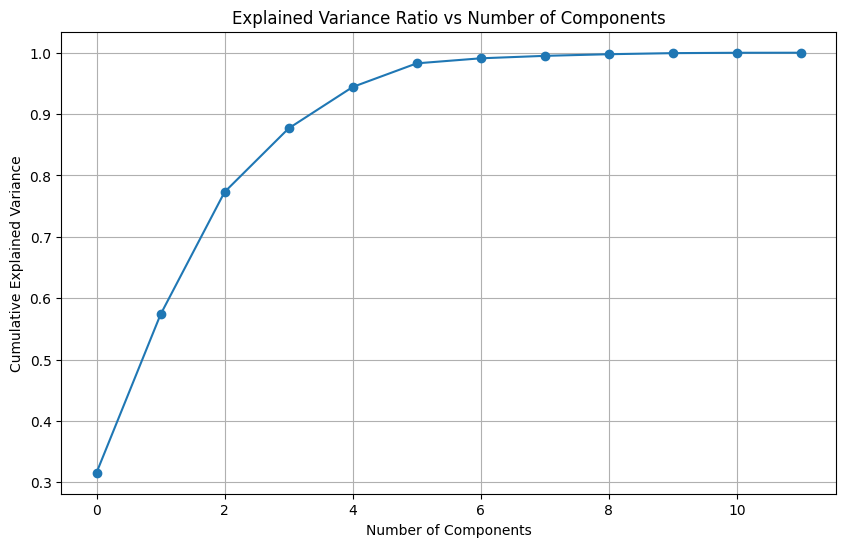

In [22]:
pca = PCA()

# Fit PCA to the data
pca.fit(X)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plotting the explained variance ratio to find the elbow point
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(explained_variance_ratio), marker='o', linestyle='-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Ratio vs Number of Components')
plt.grid(True)
plt.show()

In [23]:
# Find the elbow point programmatically
cumulative_variance = np.cumsum(explained_variance_ratio)
rate_of_change = np.diff(cumulative_variance)
elbow_index = np.argmax(rate_of_change < 0.01)
best_n_components = elbow_index + 1

print("Best number of components:", best_n_components)

Best number of components: 6


In [24]:
# Perform PCA with the optimal number of components
pca = PCA(n_components=best_n_components)

# Fit and transform the data
X_dimen = pca.fit_transform(X)

### **Data Split**

In [25]:
X_train_set, X_test_set, y_train_target, y_test_target = train_test_split(X_dimen, y, test_size=0.2, random_state=10)

# Print the shapes of the training and testing sets
print("Shape of X_train_set:", X_train_set.shape)
print("Shape of X_test_set:", X_test_set.shape)

print("Shape of y_train_target:", y_train_target.shape)
print("Shape of y_test_target:", y_test_target.shape)

Shape of X_train_set: (13114, 6)
Shape of X_test_set: (3279, 6)
Shape of y_train_target: (13114,)
Shape of y_test_target: (3279,)


### **Model Building and Training**



In [26]:
# Model 1: ExtraTrees Regression
from sklearn.ensemble import ExtraTreesRegressor

et_reg = ExtraTreesRegressor()
et_reg.fit(X_train_set, y_train_target)
et_reg_predictions = et_reg.predict(X_test_set)

In [27]:
et_mae = mean_absolute_error(y_test_target, et_reg_predictions)
et_mse = mean_squared_error(y_test_target, et_reg_predictions)
et_rmse = np.sqrt(et_mse)

print("ExtraTrees Regression:")
print("MAE:", et_mae)
print("MSE:", et_mse)
print("RMSE:", et_rmse)

ExtraTrees Regression:
MAE: 7.0170692284233
MSE: 126.76845242451967
RMSE: 11.259149720317234


In [28]:
# Model 2: Decision Tree Regression
decision_tree_reg = DecisionTreeRegressor(random_state=10)
decision_tree_reg.fit(X_train_set, y_train_target)
decision_tree_predictions = decision_tree_reg.predict(X_test_set)

In [29]:
# Decision Tree Regression
decision_tree_mae = mean_absolute_error(y_test_target, decision_tree_predictions)
decision_tree_mse = mean_squared_error(y_test_target, decision_tree_predictions)
decision_tree_rmse = np.sqrt(decision_tree_mse)

print("Decision Tree Regression:")
print("MAE:", decision_tree_mae)
print("MSE:", decision_tree_mse)
print("RMSE:", decision_tree_rmse)

Decision Tree Regression:
MAE: 9.443732845379689
MSE: 358.98261665141814
RMSE: 18.94683658691915


In [30]:
# Model 3: Random Forest Regression
random_forest_reg = RandomForestRegressor(random_state=10)
random_forest_reg.fit(X_train_set, y_train_target)
random_forest_predictions = random_forest_reg.predict(X_test_set)

In [31]:
# Random Forest Regression
random_forest_mae = mean_absolute_error(y_test_target, random_forest_predictions)
random_forest_mse = mean_squared_error(y_test_target, random_forest_predictions)
random_forest_rmse = np.sqrt(random_forest_mse)

print("Random Forest Regression:")
print("MAE:", random_forest_mae)
print("MSE:", random_forest_mse)
print("RMSE:", random_forest_rmse)

Random Forest Regression:
MAE: 7.421799329063738
MSE: 153.99052265934736
RMSE: 12.409291787178967


In [32]:
# Calculating R-squared score for each model
et_r2 = r2_score(y_test_target, et_reg_predictions)
decision_tree_r2 = r2_score(y_test_target, decision_tree_predictions)
random_forest_r2 = r2_score(y_test_target, random_forest_predictions)


print("ExtraTrees Regression:", et_r2)
print("Decision Tree Regression:", decision_tree_r2)
print("Random Forest Regression:", random_forest_r2)

ExtraTrees Regression: 0.9362465444292154
Decision Tree Regression: 0.8194631088125243
Random Forest Regression: 0.922556221544709


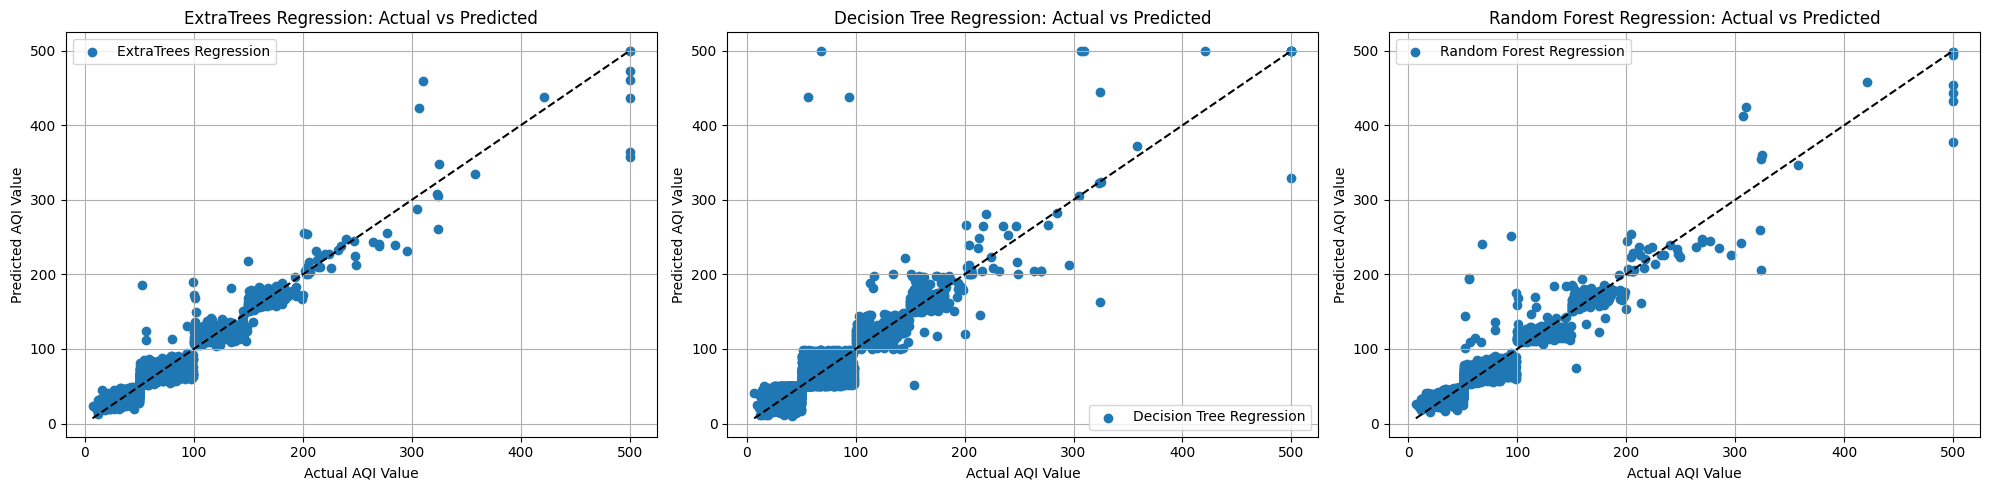

In [33]:
# List of regression models and their predictions
models = ['ExtraTrees Regression', 'Decision Tree Regression', 'Random Forest Regression']
predictions = [et_reg_predictions, decision_tree_predictions, random_forest_predictions]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))
for i, (model, prediction) in enumerate(zip(models, predictions)):

    axes[i].scatter(y_test_target, prediction, label=model)
    axes[i].plot([min(y_test_target), max(y_test_target)], [min(y_test_target), max(y_test_target)], color='black', linestyle='--')
    axes[i].set_xlabel('Actual AQI Value')
    axes[i].set_ylabel('Predicted AQI Value')
    axes[i].set_title(f'{model}: Actual vs Predicted')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

#### Comparative Performance

1. R2 Score
2. MSE
3. MAE
4. RMSE

In [34]:
r2_scores = [et_r2, decision_tree_r2, random_forest_r2]
mse_scores = [et_mse, decision_tree_mse, random_forest_mse]
mae_scores = [et_mae, decision_tree_mae, random_forest_mae]
rmse_scores = [et_rmse, decision_tree_rmse, random_forest_rmse]

metrics = ['R-squared Score', 'Mean Squared Error (MSE)', 'Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)']
scores = [r2_scores, mse_scores, mae_scores, rmse_scores]

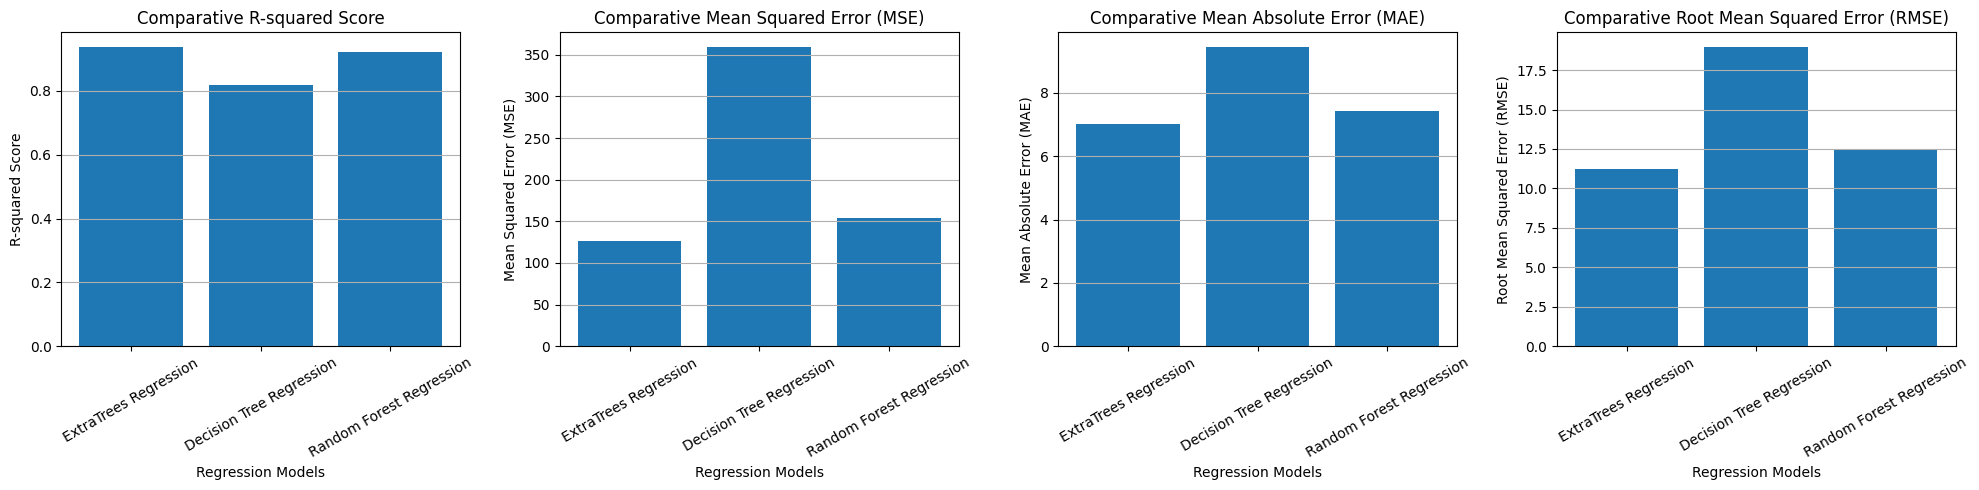

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))

for i, (metric, score) in enumerate(zip(metrics, scores)):
    axes[i].bar(models, score)
    axes[i].set_xlabel('Regression Models')
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'Comparative {metric}')
    axes[i].grid(axis='y')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [36]:
final_scores_dict = {
    'Model': models,
    'R-squared Score': r2_scores,
    'Mean Squared Error (MSE)': mse_scores,
    'Mean Absolute Error (MAE)': mae_scores,
    'Root Mean Squared Error (RMSE)': rmse_scores
}
final_scores_df = pd.DataFrame(final_scores_dict)
final_scores_df.set_index('Model', inplace=True)

In [37]:
final_scores_df

,R-squared Score,Mean Squared Error (MSE),Mean Absolute Error (MAE),Root Mean Squared Error (RMSE)
Model,,,,
ExtraTrees Regression,0.936247,126.768452,7.017069,11.259150
Decision Tree Regression,0.819463,358.982617,9.443733,18.946837
Random Forest Regression,0.922556,153.990523,7.421799,12.409292


### Hyperparameter Tuning

In [38]:
# Hyperparameter Tuning on Decision Trees Regression
from sklearn.model_selection import GridSearchCV

dt_reg_tuned = DecisionTreeRegressor()

param_grid = {
    'max_depth':[3,5,7],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid_dt = GridSearchCV(dt_reg_tuned, param_grid, cv=3, scoring='r2')
grid_dt.fit(X_train_set, y_train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is a

In [39]:
best_dt_model = grid_dt.best_estimator_

dt_tuned_predictions = best_dt_model.predict(X_test_set)

print("Best Parameters:", grid_dt.best_params_)


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [40]:
# Tuned Decision Tree Regression
dt_tuned_mae = mean_absolute_error(y_test_target, dt_tuned_predictions)
dt_tuned_mse = mean_squared_error(y_test_target, dt_tuned_predictions)
dt_tuned_rmse = np.sqrt(dt_tuned_mse)
dt_tuned_r2 = r2_score(y_test_target, dt_tuned_predictions)

print("ExtraTrees Regression:")
print("MAE:", dt_tuned_mae)
print("MSE:", dt_tuned_mse)
print("RMSE:", dt_tuned_rmse)
print("R2 Score:", dt_tuned_r2)

ExtraTrees Regression:
MAE: 9.431676039311407
MSE: 239.1100475071662
RMSE: 15.463183614869424
R2 Score: 0.8797485375996608


We can clearly see that normal decision tree model was giving 0.82 R2 score but when we performed hyperparameter tuning, the performance of model was improved as it was trained on best parameter and gave improved score as 0.879 R2.

In [41]:
with open("best_extratrees_model.pkl", "wb") as f:
    pickle.dump(et_reg, f)

In [42]:
pickle.dump(scaler, open("scaler.pkl","wb"))

pickle.dump(pca, open("pca.pkl","wb"))